In [ ]:
#| default_exp pr_geometry_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Pairwise Relation Geometry

## Diagnostics via Projection into a Low-Dimensional Space
> provides geometric, manifold‑level diagnostic layer

In [ ]:
#| eval: false
from fhemb.utils.cutils import plot_pr_projection

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-04 18:03:19.427216: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more

In [ ]:
#| eval: false

from nbdev_fhemb.module_functions_ex import Xdm

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances: 100%|██████████| 2080/2080 [00:31<00:00, 65.89it/s] 
 [WARNING] cutils.plot_pr_projection: PCA on distance-correlation matrices behaves like kernel PCA. Consider MDS or TSNE for distance-based projections.


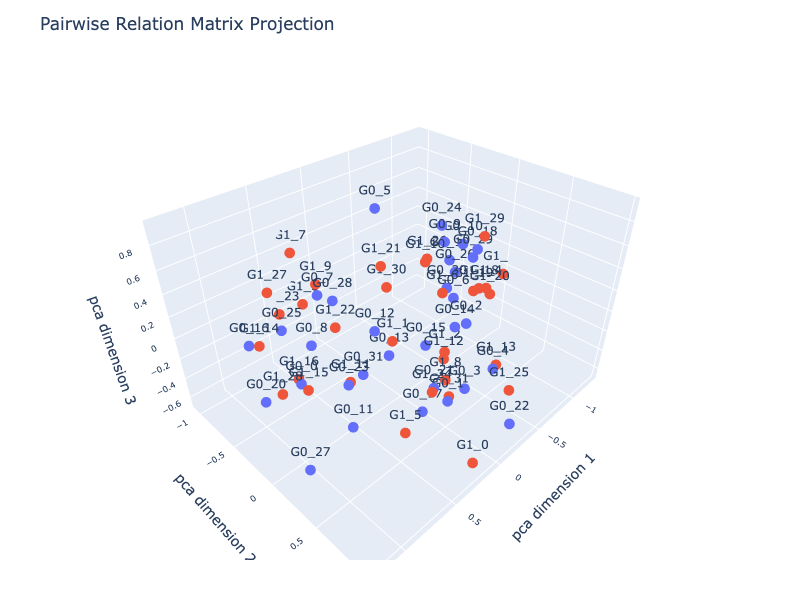

In [ ]:
#| eval: false

plot_pr_projection(
    Xdm[:32], Xdm[32:],         # data matrices for two groups (32 x 64)
    alignment_type='dcor',      # alignment method for distance matrix computation           
    projection='pca',           # projection method for dimensionality reduction ('pca', 'tsne', 'mds') 
    n_jobs=8,                   # number of jobs for parallelization
    dimensions=3,               # number of dimensions of the projection
) 

In [ ]:
#| eval: false
from scipy.spatial.distance import (
    euclidean, 
    cityblock, 
    cosine, 
    mahalanobis, 
    sqeuclidean, 
    chebyshev, 
    minkowski, 
    braycurtis, 
    canberra, 
    correlation, 
    jaccard, 
    hamming
)

 [INFO] cutils.calc_pairwise_relation: Using cosine alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances: 100%|██████████| 2080/2080 [01:28<00:00, 23.38it/s]


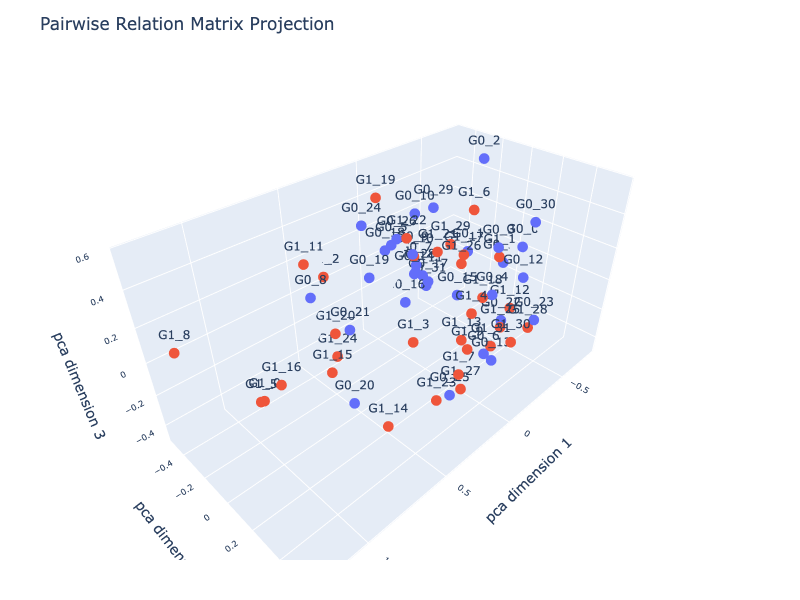

In [ ]:
#| eval: false

plot_pr_projection(
    Xdm[:32], Xdm[32:],         # data matrices for two groups (32 x 64)
    alignment_type='fastdtw',   # alignment method for distance matrix computation           
    dist=cosine,                # alignment metric function used inside fastdtw     
    projection='pca',           # projection method for dimensionality reduction ('pca', 'tsne', 'mds') 
    transformation='minmax',    # to transform distances into similarities for PCA
    normalize='log',            # normalization method for a 'pca' projection of a DTW alignment type
    n_jobs=8,                   # number of jobs for parallelization
    dimensions=3,               # number of dimensions of the projection
) 

::: {.callout-note title="Distance-matrix projection diagnostics"}
Look for: 

- **Compact groups** → evidence of cluster structure in the underlying time series
- **Overlapping or diffuse clouds** → weak or ambiguous cluster boundaries
- **Isolated points** → outlier time series with atypical temporal behavior
- **Arcs, curves, or gradients** → continuous progression rather than discrete clusters
- **Changes across preprocessing steps** → reveals whether normalization or filtering improves separability
- **Metric comparison** → different distance metrics produce different geometries; projection shows how strongly
- **A sanity check**: it shows whether the DTW geometry contains meaningful structure before applying any clustering algorithm.
:::

## Diagnostics via Singular Value Decomposition (SVD)  

::: {.callout-note collapse="false" title="svd_matrix"}
`svd_matrix(X, alignment_type, gamma, transformation, normalize, n_jobs)`  
Computes a **low‑rank decomposition** of a distance‑based similarity matrix using **Singular Value Decomposition (SVD)**.  
This function helps analyze the structure of the similarity geometry and estimate the **intrinsic dimensionality** of the dataset.

**Pipeline**
1. Compute pairwise distances using `alignment_type` (e.g., `fastdtw`).  
2. Convert distances into similarities using `transformation` (e.g., `gauss`, `invert`, `minmax`).  
3. Optionally normalize time series using `normalize`.  
4. Apply SVD to the resulting similarity matrix $\qquad K = U \Sigma V^\top$

**Returns**
- `U` — left singular vectors  
- `S` — singular values  
- `Vt` — right singular vectors  

**Interpretation**
- Singular values `S` quantify how much structure each latent dimension explains.  
- Their decay provides a practical estimate of the **intrinsic dimension** of the similarity space:  
  - sharp drop → low intrinsic dimension  
  - gradual decay → diffuse or noisy structure  
- Conceptually similar to PCA, but applied directly to the **similarity matrix** rather than centered feature data.

**Use cases**
- Inspecting geometric structure before embedding  
- Choosing the number of PCA/MDS components  
- Detecting noise vs. signal in distance‑based representations  
- Low‑rank smoothing or compression of similarity matrices
:::

##### Calculate singular-value spectrum

In [ ]:
#| eval: false
from fhemb.utils.cutils import svd_pr

In [ ]:
#| eval: false

U, S, Vt = svd_pr(       # returns U, S, Vt matrices from SVD of the distance matrix
    Xdm,                      # data matrix (64 x 64)
    alignment_type='fastdtw', # alignment method for distance matrix computation
    dist=cosine,              # alignment metric function used inside fastdtw
    radius=2,                 # refinement window size in fastdtw
    transformation='minmax',  # to transform distances into similarities for SVD
    normalize='log',          # normalization method for a DTW alignment type
    n_jobs=8                  # number of jobs for parallelization
)

 [INFO] cutils.calc_pairwise_relation: Using cosine alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances: 100%|██████████| 2080/2080 [02:41<00:00, 12.90it/s]


##### Visualize the singular-value spectrum
>The vector S contains the singular values returned by the SVD. By convention, these values are sorted in descending order, so the first one corresponds to the dominant singular value and subsequent entries decrease monotonically.

In [ ]:
#| eval: false
import matplotlib.pyplot as plt

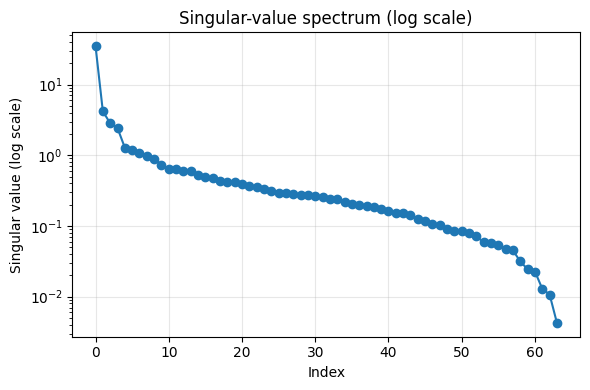

In [ ]:
#| eval: false

plt.figure(figsize=(6, 4))
plt.semilogy(S, marker='o', linewidth=1.5)
plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.title("Singular-value spectrum (log scale)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

::: {.callout-note title="Intrinsic Dimensionality"}
The singular-value spectrum exhibits a sharp decay after the first four components. This indicates that the matrix is well-approximated by a rank‑4 model, and that the intrinsic dimensionality of the similarity structure is approximately four. Components beyond the fourth lie near the noise floor and contribute minimally to the geometry of the space.
:::